#  Ames Housing — Regression Modeling

**Project:** Real Estate Price Analysis — Ames, Iowa  
**Author:** A.K  
**Phase:** 5 of 7 — Modeling (CRISP-DM)

## Objective
Train and evaluate multiple regression models to predict house sale prices.
Models are built in order of complexity — each addressing a weakness of the previous.

## Models
1. Linear Regression — interpretable baseline
2. Ridge Regression — penalizes large coefficients, handles multicollinearity
3. Lasso Regression — shrinks weak features to zero (automatic selection)
4. Gradient Boosting — captures non-linear relationships

## Metric
Primary: RMSE on log(SalePrice) — lower is better  
Secondary: R² — proportion of price variance explained (higher is better)  
We report RMSE in original dollar scale for stakeholder readability.

A. Import & Load Data

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [31]:
#Load feature matrix and target:

X = pd.read_csv('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\00 Data\\Feature Matrix Data\\X_features.csv')
y = pd.read_csv('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\00 Data\\Feature Matrix Data\\y_target.csv').squeeze()

print(f"Feature matrix : {X.shape}")
print(f"Target vector  : {y.shape}")
print(f"Target preview : {y.describe().round(4)}")

Feature matrix : (2927, 238)
Target vector  : (2927,)
Target preview : count    2927.0000
mean       12.0209
std         0.4078
min         9.4564
25%        11.7714
50%        11.9829
75%        12.2714
max        13.5345
Name: SalePrice_Log, dtype: float64


B. Train/Test Split

In [32]:
#Split before any model sees the data:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42      # reproducibility — same split every run
)

print(f"Training set   : {X_train.shape[0]:,} houses")
print(f"Test set       : {X_test.shape[0]:,} houses")
print(f"Test size      : {X_test.shape[0]/len(X)*100:.1f}%")

Training set   : 2,341 houses
Test set       : 586 houses
Test size      : 20.0%


C. Evaluation Helper Function

In [33]:
#Reusable evaluation function:

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """
    Training a model, to evaluate on train and test sets,
    and return metrics in original dollar scale.
    """
    model.fit(X_tr, y_tr)

    # Predictions (log scale):

    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    # Metrics on log scale:

    rmse_train = np.sqrt(mean_squared_error(y_tr, y_pred_train))
    rmse_test  = np.sqrt(mean_squared_error(y_te, y_pred_test))
    r2_train   = r2_score(y_tr, y_pred_train)
    r2_test    = r2_score(y_te, y_pred_test)

    # Correct dollar RMSE calculation
    # Convert BOTH actual and predicted back to dollar scale first,
    # then compute RMSE between them in dollars:

    actual_dollars    = np.expm1(y_te.values)
    predicted_dollars = np.expm1(y_pred_test)
    dollar_rmse = np.sqrt(mean_squared_error(actual_dollars, predicted_dollars))

    # Cross-validation RMSE (5-fold):
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_tr, y_tr,
                                 scoring='neg_root_mean_squared_error',
                                 cv=kf)
    cv_rmse = -cv_scores.mean()

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Train RMSE   : {rmse_train:.4f}  |  R²: {r2_train:.4f}")
    print(f"  Test  RMSE   : {rmse_test:.4f}  |  R²: {r2_test:.4f}")
    print(f"  CV RMSE      : {cv_rmse:.4f} (5-fold)")
    print(f"  Dollar RMSE  : ${dollar_rmse:,.0f}")

    return {
        'Model': name,
        'Train RMSE': round(rmse_train, 4),
        'Test RMSE':  round(rmse_test, 4),
        'CV RMSE':    round(cv_rmse, 4),
        'Test R²':    round(r2_test, 4),
        'Dollar RMSE': round(dollar_rmse, 0)
    }

print("Evaluation function defined ✓")

Evaluation function defined ✓


## Model 1 — Linear Regression (Baseline)

The simplest possible model. Assumes a straight-line relationship between
each feature and log(SalePrice). No regularization — every feature is used
at full weight regardless of relevance.

**Expected weakness:** With 200+ features, many of which are correlated,
coefficients will be unstable. This gives us our baseline to beat.

D. Linear Regression

In [34]:
results = []  # collect all model results here

lr = LinearRegression()
lr_results = evaluate_model(
    'Linear Regression', lr,
    X_train, X_test, y_train, y_test
)
results.append(lr_results)
joblib.dump(lr, 'C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\04 Regression\\Models\\model_linear.pkl')
print("\nModel saved → model_linear.pkl")


  Linear Regression
  Train RMSE   : 0.1022  |  R²: 0.9359
  Test  RMSE   : 0.1038  |  R²: 0.9400
  CV RMSE      : 0.1311 (5-fold)
  Dollar RMSE  : $19,100

Model saved → model_linear.pkl


## Model 2 — Ridge Regression (L2 Regularization)

Ridge adds a penalty term to the loss function that discourages large coefficients.
When features are correlated (as we saw in EDA — Gr Liv Area ↔ TotRms),
ordinary linear regression assigns unstable, extreme weights.
Ridge shrinks all coefficients toward zero — keeping all features
but reducing their extremity.

The strength of the penalty is controlled by `alpha`:
- alpha=0 → identical to Linear Regression
- higher alpha → stronger shrinkage

We search for the best alpha using cross-validation.

E. Ridge Regression

In [35]:
from sklearn.linear_model import RidgeCV

# RidgeCV tests multiple alpha values and selects the best automatically:

ridge = RidgeCV(
    alphas=[0.1, 1, 5, 10, 20, 50, 100, 200],
    cv=5
)

ridge_results = evaluate_model(
    'Ridge Regression', ridge,
    X_train, X_test, y_train, y_test
)
results.append(ridge_results)

print(f"\nBest alpha selected: {ridge.alpha_}")
joblib.dump(ridge, 'C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\04 Regression\\Models\\model_ridge.pkl')
print("Model saved → model_ridge.pkl")


  Ridge Regression
  Train RMSE   : 0.1045  |  R²: 0.9329
  Test  RMSE   : 0.0961  |  R²: 0.9486
  CV RMSE      : 0.1217 (5-fold)
  Dollar RMSE  : $18,342

Best alpha selected: 200.0
Model saved → model_ridge.pkl


## Model 3 — Lasso Regression (L1 Regularization)

Lasso applies a different penalty that drives weak feature coefficients
exactly to zero — effectively removing them from the model.

Where Ridge keeps all 200+ features at reduced weights,
Lasso performs automatic feature selection.
This gives us a leaner, more interpretable model.

The features Lasso keeps are the ones with the strongest genuine
relationship to price — a direct answer to "what actually matters?"

F. Lasso Regression

In [36]:
from sklearn.linear_model import LassoCV

# LassoCV finds best alpha via cross-validation:

lasso = LassoCV(
    alphas=[0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1],
    cv=5,
    max_iter=10000
)

lasso_results = evaluate_model(
    'Lasso Regression', lasso,
    X_train, X_test, y_train, y_test
)
results.append(lasso_results)

# How many features did Lasso keep?

n_zero     = np.sum(lasso.coef_ == 0)
n_nonzero  = np.sum(lasso.coef_ != 0)
print(f"\nBest alpha selected : {lasso.alpha_:.5f}")
print(f"Features kept       : {n_nonzero}")
print(f"Features zeroed out : {n_zero}")

joblib.dump(lasso, 'C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\04 Regression\\Models\\model_lasso.pkl')
print("Model saved → model_lasso.pkl")


  Lasso Regression
  Train RMSE   : 0.1050  |  R²: 0.9323
  Test  RMSE   : 0.0948  |  R²: 0.9500
  CV RMSE      : 0.1235 (5-fold)
  Dollar RMSE  : $18,594

Best alpha selected : 0.00100
Features kept       : 165
Features zeroed out : 73
Model saved → model_lasso.pkl


G. Lasso Feature Importance

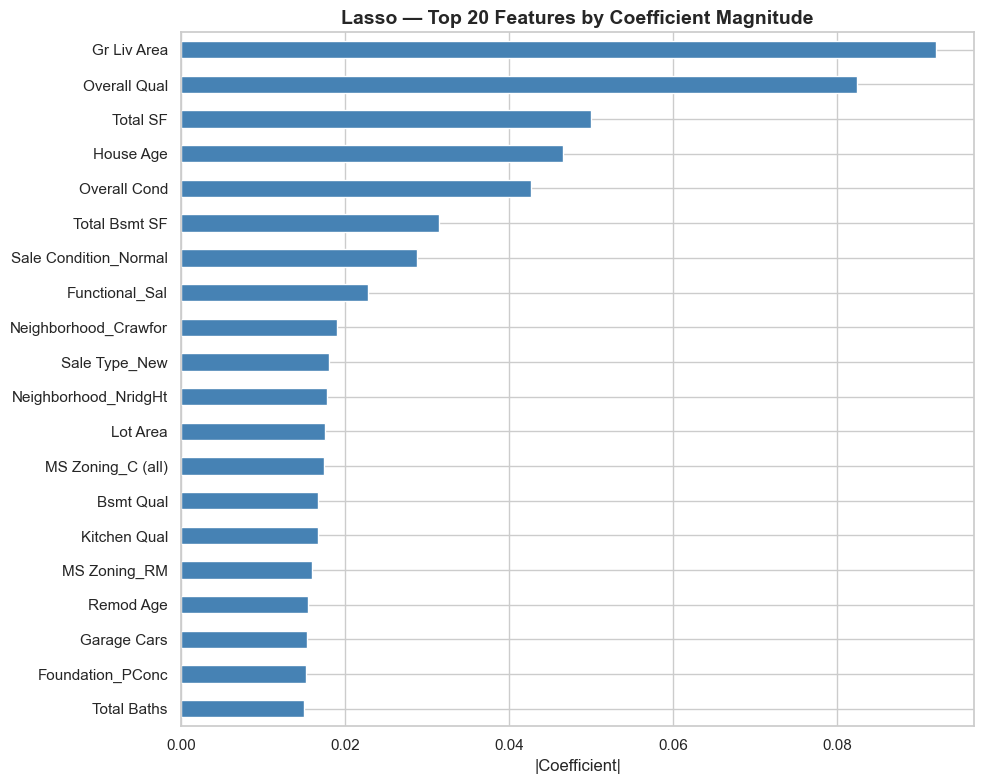

In [37]:
# Which features did Lasso consider most important?

lasso_coef = pd.Series(lasso.coef_, index=X.columns)
top_lasso = lasso_coef.abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
top_lasso.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Lasso — Top 20 Features by Coefficient Magnitude', fontsize=14, fontweight='bold')
ax.set_xlabel('|Coefficient|')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\04 Regression\\Report\\lasso_feature_importance.png', dpi=150)
plt.show()

## Model 4 — Gradient Boosting Regressor

Gradient Boosting builds an ensemble of decision trees sequentially.
Each tree corrects the errors of the previous one.

Unlike linear models, it:
- Captures non-linear relationships (price doesn't always scale linearly with size)
- Handles feature interactions automatically
- Does not require the target to be normally distributed

This is our most powerful model. The trade-off is interpretability —
it is harder to explain to a non-technical stakeholder than Ridge or Lasso.

In [38]:
gb = GradientBoostingRegressor(
    n_estimators=500,      # number of trees
    learning_rate=0.05,    # how much each tree corrects
    max_depth=4,           # depth of each tree
    min_samples_leaf=15,   # prevents overfitting on small groups
    random_state=42
)

gb_results = evaluate_model(
    'Gradient Boosting', gb,
    X_train, X_test, y_train, y_test
)
results.append(gb_results)
joblib.dump(gb, 'C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\04 Regression\\Models\\model_gb.pkl')
print("Model saved → model_gb.pkl")


  Gradient Boosting
  Train RMSE   : 0.0610  |  R²: 0.9772
  Test  RMSE   : 0.0992  |  R²: 0.9452
  CV RMSE      : 0.1249 (5-fold)
  Dollar RMSE  : $20,721
Model saved → model_gb.pkl


H. Gradient Boosting Feature Importance

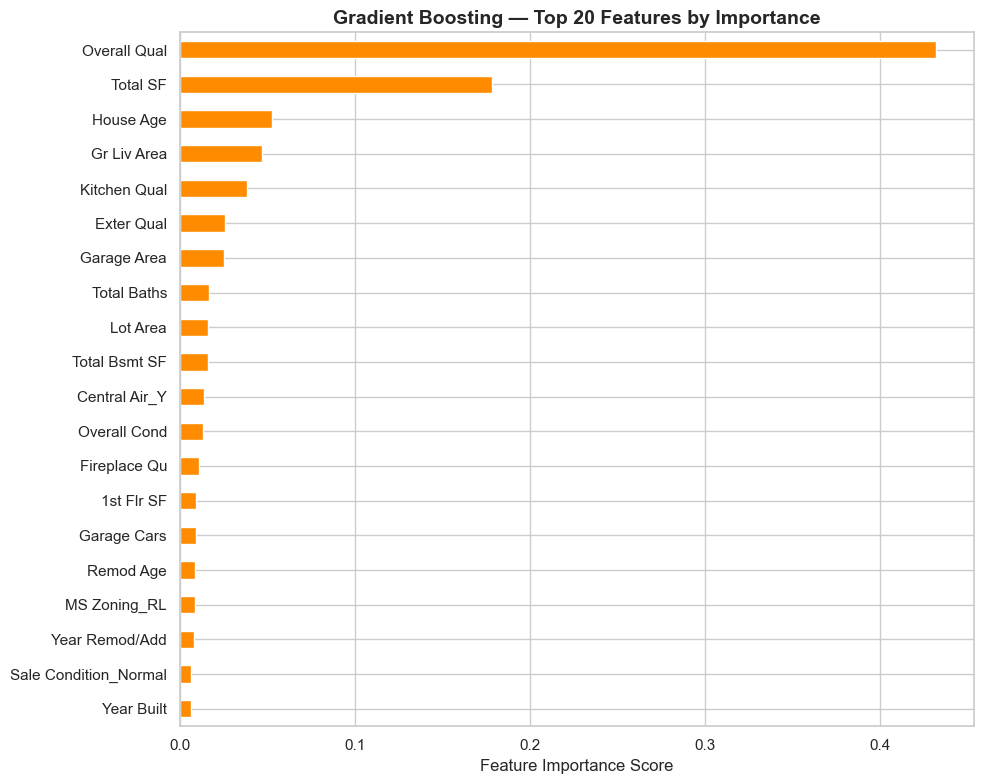

In [39]:
gb_importance = pd.Series(gb.feature_importances_, index=X.columns)
top_gb = gb_importance.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
top_gb.plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('Gradient Boosting — Top 20 Features by Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\04 Regression\\Report\\gb_feature_importance.png', dpi=150)
plt.show()

I. Residual Plots

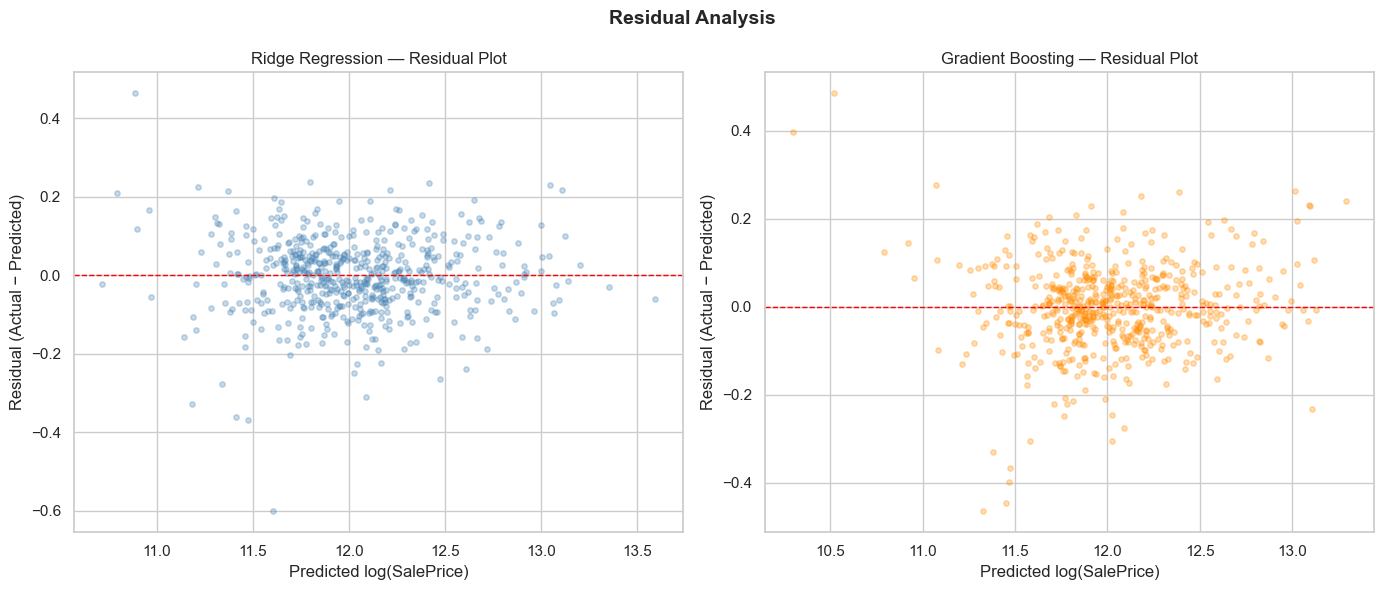

In [40]:
# Residuals reveal WHERE and HOW a model fails:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Best linear model (Ridge) vs best overall (GB):

for ax, model, name, color in zip(
    axes,
    [ridge, gb],
    ['Ridge Regression', 'Gradient Boosting'],
    ['steelblue', 'darkorange']
):
    y_pred = model.predict(X_test)
    residuals = y_test.values - y_pred

    ax.scatter(y_pred, residuals, alpha=0.3, color=color, s=15)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Predicted log(SalePrice)')
    ax.set_ylabel('Residual (Actual − Predicted)')
    ax.set_title(f'{name} — Residual Plot')

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\04 Regression\\Report\\residual_plots.png', dpi=150)
plt.show()

J. Actual vs Predicted Plot

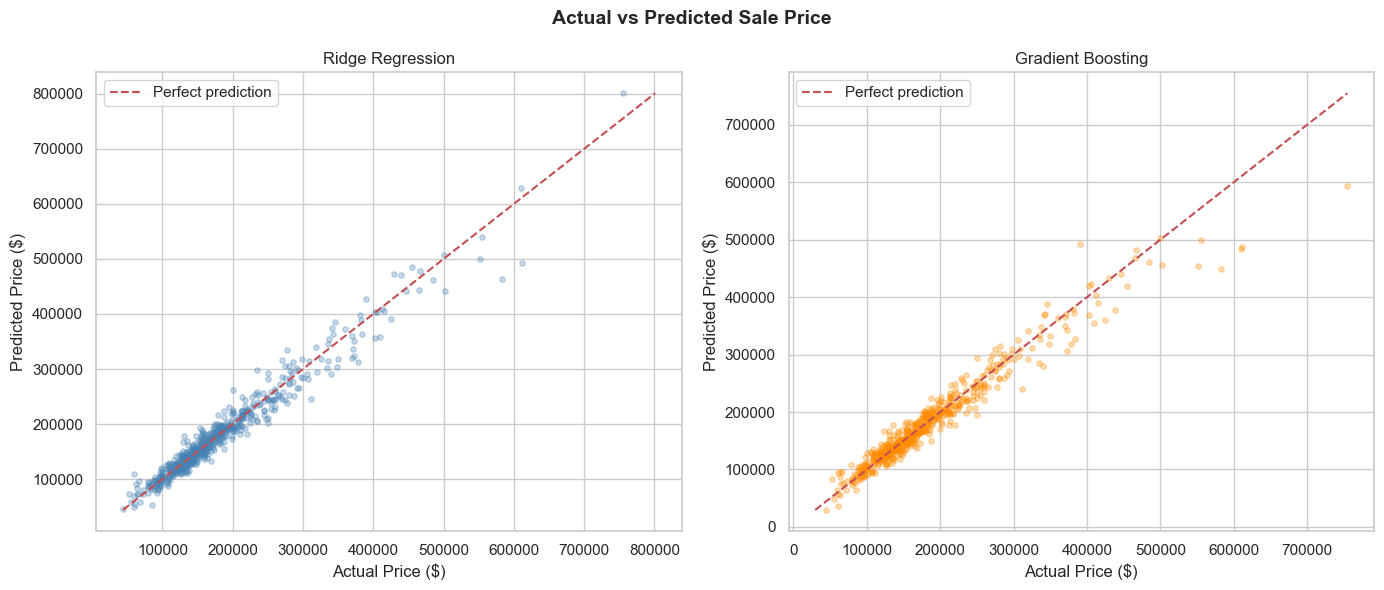

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, name, color in zip(
    axes,
    [ridge, gb],
    ['Ridge Regression', 'Gradient Boosting'],
    ['steelblue', 'darkorange']
):
    y_pred = model.predict(X_test)
    # Convert back from log scale to dollars
    actual_dollars    = np.expm1(y_test.values)
    predicted_dollars = np.expm1(y_pred)

    ax.scatter(actual_dollars, predicted_dollars, alpha=0.3, color=color, s=15)
    # Perfect prediction line
    min_val = min(actual_dollars.min(), predicted_dollars.min())
    max_val = max(actual_dollars.max(), predicted_dollars.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Price ($)')
    ax.set_ylabel('Predicted Price ($)')
    ax.set_title(f'{name}')
    ax.legend()

plt.suptitle('Actual vs Predicted Sale Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\04 Regression\\Report\\actual_vs_predicted.png', dpi=150)
plt.show()

K. Model Comparison Table


MODEL COMPARISON SUMMARY
                   Train RMSE  Test RMSE  CV RMSE  Test R²  Dollar RMSE
Model                                                                  
Linear Regression      0.1022     0.1038   0.1311   0.9400      19100.0
Ridge Regression       0.1045     0.0961   0.1217   0.9486      18342.0
Lasso Regression       0.1050     0.0948   0.1235   0.9500      18594.0
Gradient Boosting      0.0610     0.0992   0.1249   0.9452      20721.0


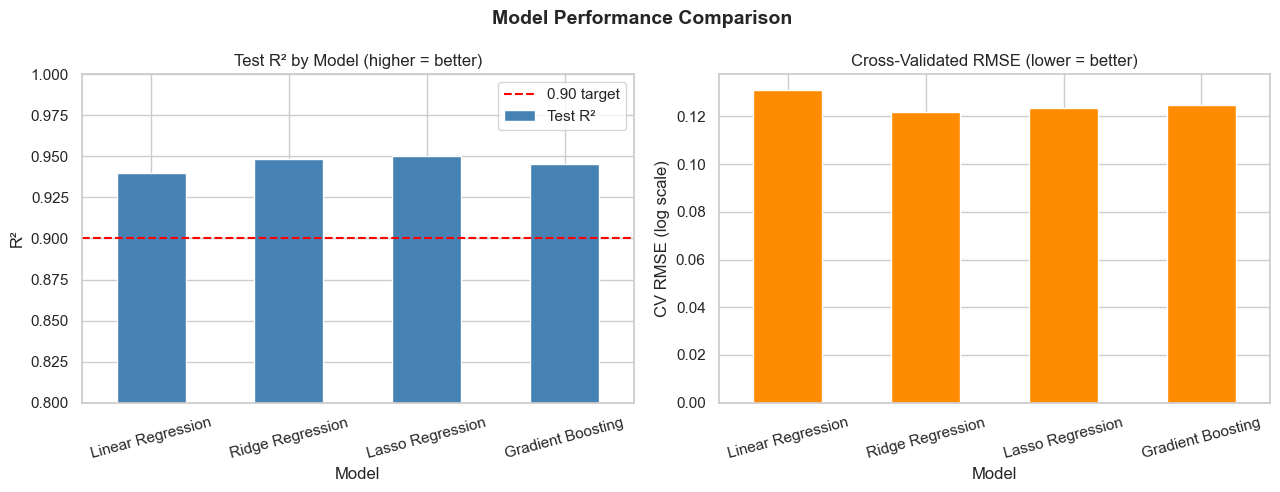

In [42]:
# Compile all results:

results_df = pd.DataFrame(results).set_index('Model')
print("\n" + "="*65)
print("MODEL COMPARISON SUMMARY")
print("="*65)
print(results_df.to_string())
print("="*65)

# Visual comparison — Test R²:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

results_df['Test R²'].plot(
    kind='bar', ax=axes[0], color='steelblue',
    edgecolor='white', rot=15
)
axes[0].set_title('Test R² by Model (higher = better)', fontsize=12)
axes[0].set_ylabel('R²')
axes[0].set_ylim(0.8, 1.0)
axes[0].axhline(y=0.9, color='red', linestyle='--', label='0.90 target')
axes[0].legend()

results_df['CV RMSE'].plot(
    kind='bar', ax=axes[1], color='darkorange',
    edgecolor='white', rot=15
)
axes[1].set_title('Cross-Validated RMSE (lower = better)', fontsize=12)
axes[1].set_ylabel('CV RMSE (log scale)')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\04 Regression\\Report\\model_comparison.png', dpi=150)
plt.show()

L. Save Best Model & Predictions

In [43]:
# Identify best model by CV RMSE (most honest metric):

best_name = results_df['CV RMSE'].idxmin()
print(f"Best model by CV RMSE: {best_name}")

# Save final predictions in dollar scale for the dashboard:

best_model = {'Linear Regression': lr,
              'Ridge Regression': ridge,
              'Lasso Regression': lasso,
              'Gradient Boosting': gb}[best_name]

predictions_df = pd.DataFrame({
    'Actual_Price':    np.expm1(y_test.values),
    'Predicted_Price': np.expm1(best_model.predict(X_test)),
    'Residual':        y_test.values - best_model.predict(X_test)
})

predictions_df.to_csv('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\04 Regression\\Best Model\\predictions.csv', index=False)
joblib.dump(best_model, 'C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\04 Regression\\Best Model\\best_model.pkl')

print(f"predictions.csv saved → {predictions_df.shape}")
print(f"best_model.pkl saved")

Best model by CV RMSE: Ridge Regression
predictions.csv saved → (586, 3)
best_model.pkl saved
